In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [22]:
df = pd.read_csv("MagicBricksProject_Cleaned_Data.csv")

In [23]:
df.head(5)

,City,BHK,Location,Price,Area (sqft),Property Type,Furnishing,Property Facing,overlooking,Bathroom,Balcony,Tenant Preferred,Availability
0,Hyderabad,1,Kondapur,24000,450,Flat,Furnished,East,"Garden/Park, Main Road",1,1,Bachelors/Family,Immediately
1,Hyderabad,1,Kondapur,15500,800,Flat,Semi-Furnished,North,Main Road,1,1,Bachelors,Immediately
2,Hyderabad,2,Hitech City,58000,1355,Flat,Semi-Furnished,West,Garden/Park,2,1,Bachelors/Family,Immediately
3,Hyderabad,1,Kondapur,24000,450,Flat,Furnished,East,Main Road,1,1,Bachelors/Family,Immediately
4,Hyderabad,3,Kondapur,60000,1805,Flat,Unfurnished,West,"Garden/Park, Pool, Main Road",3,2,Bachelors,Immediately


In [24]:
df.tail(5)

,City,BHK,Location,Price,Area (sqft),Property Type,Furnishing,Property Facing,overlooking,Bathroom,Balcony,Tenant Preferred,Availability
1228,Chennai,3,Nungambakkam,60000,1750,Flat,Semi-Furnished,North,"Garden/Park, Main Road",3,3,Bachelors,Immediately
1229,Chennai,2,Perungudi,55000,1200,Flat,Furnished,East,Main Road,2,2,Bachelors,Immediately
1230,Chennai,3,Perungudi,90000,1850,Flat,Semi-Furnished,West,Main Road,3,1,Bachelors,From Mar '26
1231,Chennai,3,Perungudi,110000,1940,Flat,Semi-Furnished,North,"Garden/Park, Pool",3,1,Bachelors/Family,Immediately
1232,Chennai,3,Perungudi,40000,1102,Flat,Semi-Furnished,East,Main Road,2,1,Family,From Jan '26


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   City              1233 non-null   object
 1   BHK               1233 non-null   int64 
 2   Location          1233 non-null   object
 3   Price             1233 non-null   int64 
 4   Area (sqft)       1233 non-null   int64 
 5   Property Type     1233 non-null   object
 6   Furnishing        1233 non-null   object
 7   Property Facing   1233 non-null   object
 8   overlooking       1233 non-null   object
 9   Bathroom          1233 non-null   int64 
 10  Balcony           1233 non-null   int64 
 11  Tenant Preferred  1233 non-null   object
 12  Availability      1233 non-null   object
dtypes: int64(5), object(8)
memory usage: 125.4+ KB


In [26]:
df.describe(include='all')

,City,BHK,Location,Price,Area (sqft),Property Type,Furnishing,Property Facing,overlooking,Bathroom,Balcony,Tenant Preferred,Availability
count,1233,1233.000000,1233,1233.000000,1233.000000,1233,1233,1233,1233,1233.000000,1233.000000,1233,1233
unique,5,NaN,104,NaN,NaN,3,3,8,13,NaN,NaN,3,7
top,Pune,NaN,Perungudi,NaN,NaN,Flat,Semi-Furnished,East,Main Road,NaN,NaN,Bachelors/Family,Immediately
freq,276,NaN,190,NaN,NaN,1058,755,833,554,NaN,NaN,638,1149
mean,NaN,2.462287,NaN,51948.938362,1203.995945,NaN,NaN,NaN,NaN,2.399027,1.536091,NaN,NaN
std,NaN,0.723277,NaN,33103.614536,524.473325,NaN,NaN,NaN,NaN,0.714915,0.679383,NaN,NaN
min,NaN,1.000000,NaN,4500.000000,3.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,NaN,2.000000,NaN,26000.000000,800.000000,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN
50%,NaN,3.000000,NaN,45000.000000,1100.000000,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN
75%,NaN,3.000000,NaN,70000.000000,1503.000000,NaN,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN


In [27]:
print(df.isnull().sum())

City                0
BHK                 0
Location            0
Price               0
Area (sqft)         0
Property Type       0
Furnishing          0
Property Facing     0
overlooking         0
Bathroom            0
Balcony             0
Tenant Preferred    0
Availability        0
dtype: int64


### Shape of DataSet
- we have 1271 Rows 
- 13 columns


In [28]:
df.shape

(1233, 13)

# Data Handling and Cleaning Process Summary

This project involves scraping real estate data from MagicBricks, processing it into a structured format, and cleaning it for analysis. Below is a summary of the data handling steps:

## 1. Data Collection (Web Scraping)
- **Source**: MagicBricks website (Property for Rent).
- **Cities Covered**: Hyderabad, Bangalore, Mumbai, Pune, Chennai.
- **Tools Used**: `requests` for HTTP requests, `BeautifulSoup` for HTML parsing.
- **Extraction Strategy**:
  - Iterated through pages for each city (approx. 300 properties per city).
  - Extracted key details: **BHK, Location, Price, Area, Property Type, Furnishing, Facing, Overlooking, Bathroom, Balcony, Tenant Preference, Availability**.
  - Handled extraction errors using `try-except` blocks.
  - Saved raw scraped data to `MagicBricksProject_Scraped_Data.csv`.

## 2. Data Loading & Inspection

  ### Data Dictionary

| Column Name      | Description                                                      | Data Type |
|:-----------------|:-----------------------------------------------------------------|:----------|
| City             | The city where the property is located (e.g., Hyderabad).        | object    |
| BHK              | Number of Bedrooms, Hall, and Kitchen units.                     | int64     |
| Location         | Specific neighborhood or locality within the city.               | object    |
| Price            | Monthly rental price of the property in INR.                     | int64     |
| Area (sqft)      | Built-up area of the property in square feet.                    | int64     |
| Property Type    | Type of property (e.g., Flat, House, Villa).                     | object    |
| Furnishing       | Furnishing status (e.g., Furnished, Semi-Furnished).             | object    |
| Property Facing  | Cardinal direction the property faces (e.g., East, West).        | object    |
| overlooking      | Key landmarks or views visible from the property.                | object    |
| Bathroom         | Number of bathrooms available in the property.                   | int64     |
| Balcony          | Number of balconies available in the property.                   | int64     |
| Tenant Preferred | Type of tenant preferred by the owner (e.g., Bachelors, Family). | object    |
| Availability     | Possession status (e.g., Immediately, From Date).                | object    |

- Loaded the raw data into a Pandas DataFrame.
- Checked for:
  - **Missing Values**: `df.isnull().sum()`
  - **Duplicate Rows**: `df.duplicated().sum()`
  - **Data Types**: `df.dtypes`


## 3. Data Cleaning & Transformation
The following steps were taken to clean the data:

### **Handling Duplicates**
- Removed duplicate rows based on all columns to ensure data uniqueness.

### **Standardizing Categorical Data**
- **Location**:
  - Standardized location names using a predefined list of valid localities for each city.
  - Replaced empty or invalid locations with `NaN`.
  - Imputed missing locations with the **mode** (most frequent value) of the location within the respective city.
- **Property Facing**:
  - Imputed missing values with the **mode** of the facing direction within that specific location (defaulting to 'East' if undefined).
- **Other Columns**:
  - Imputed missing values for **Furnishing, Overlooking, Bathroom, Balcony, Tenant Preferred, Availability** using the global **mode** of each column.

### **Numeric Data Cleaning**
- **Price**:
  - Cleaned formatting (removed commas, '₹').
  - Converted abbreviations like 'Lac' and 'Cr' into full numeric values.
  - Converted the column to `integer`.
- **Area**:
  - Extracted numeric values from the "sqft" string using Regular Expressions (`re`).
  - Converted the column to `integer`.
- **BHK**:
  - Converted from object/string to `integer`.

## 4. Final Output
- Performed a final check for duplicates and missing values (ensuring 0 missing).
- Saved the clean, structured dataset to **`MagicBricksProject_Cleaned_Data.csv`**.

#### Purpose:

- Property price analysis
- Real estate market insights
- Predictive modeling (e.g., price estimation)
- Academic or demonstration use


In [69]:
city_colors = {'Hyderabad': '#FF6B6B', 'Bangalore': '#4ECDC4', 
               'Mumbai': '#45B7D1', 'Pune': '#FFA07A', 'Chennai': '#98D8C8'}

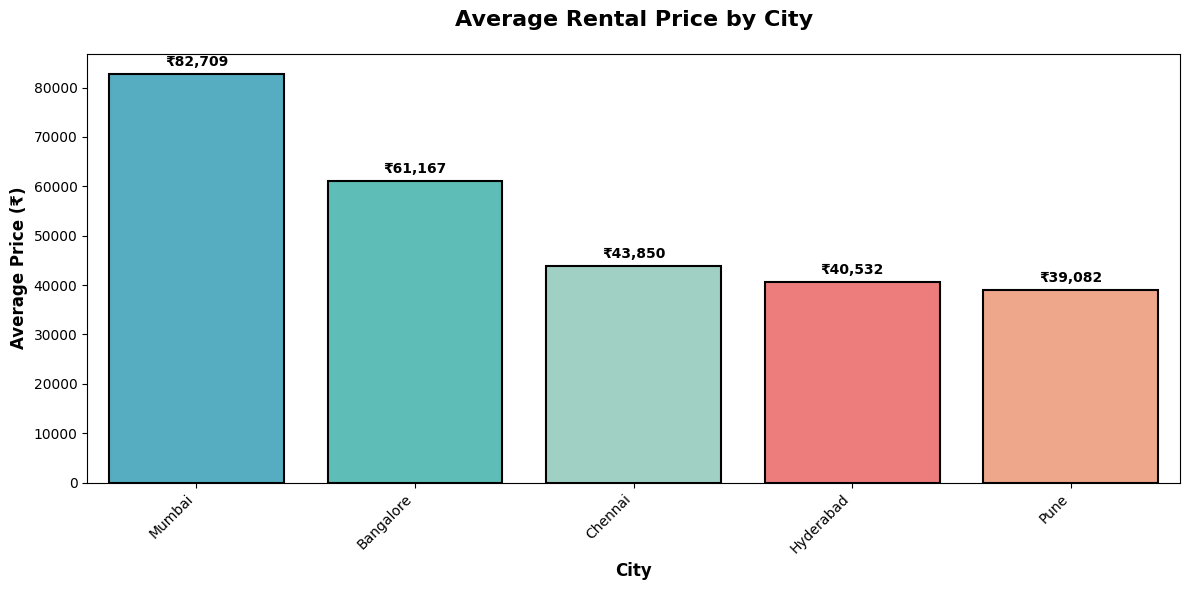

In [52]:
# ============================================================================
# 1. RENTAL PRICE DISTRIBUTION BY CITY (Enhanced Bar Plot)
# ============================================================================
# Create a color palette


plt.figure(figsize=(12, 6))
city_avg = df.groupby('City')['Price'].mean().sort_values(ascending=False)
colors_list = [city_colors[city] for city in city_avg.index]

ax = sns.barplot(x=city_avg.index, y=city_avg.values, palette=colors_list, edgecolor='black', linewidth=1.5)
plt.title('Average Rental Price by City', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for i, (city, value) in enumerate(city_avg.items()):
    ax.text(i, value + 1000, f'₹{value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('1_rental_price_by_city.png', bbox_inches='tight')
plt.show()

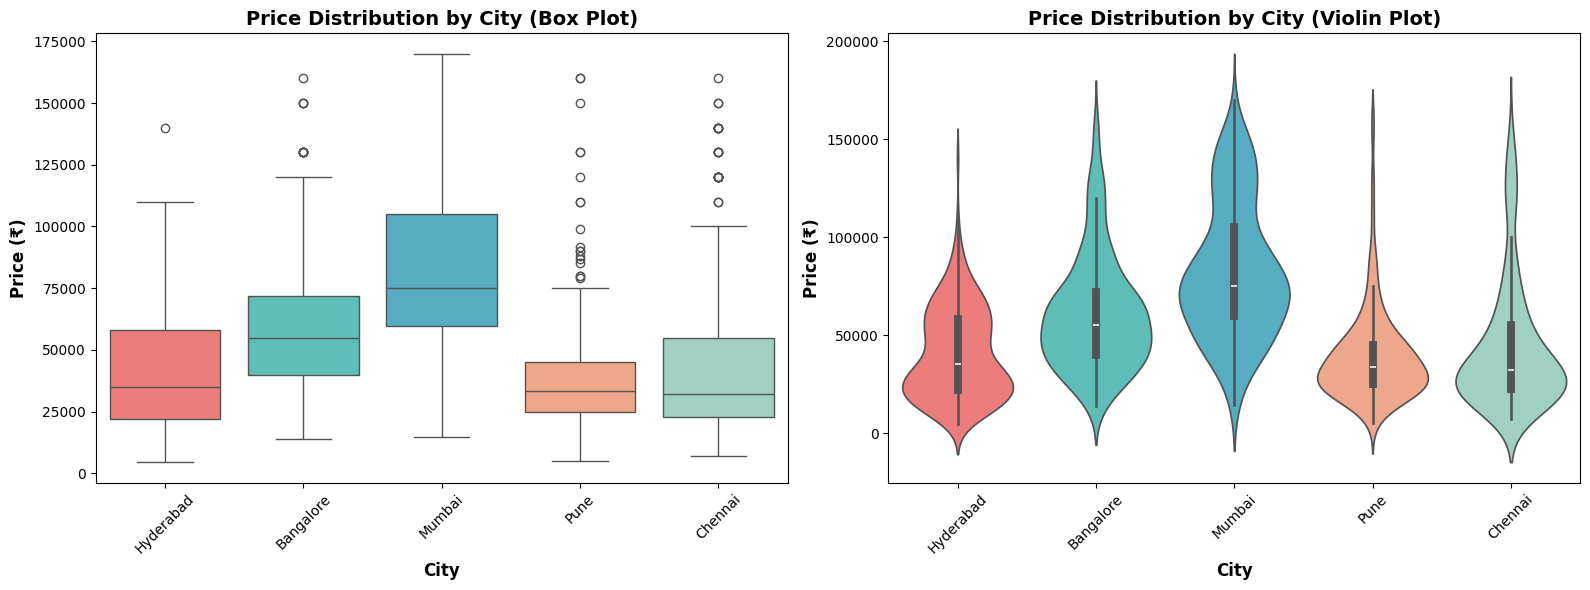

In [53]:
# ============================================================================
# 2. PRICE DISTRIBUTION (Box Plot with Violin)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df, x='City', y='Price', palette=city_colors, ax=axes[0])
axes[0].set_title('Price Distribution by City (Box Plot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (₹)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot
sns.violinplot(data=df, x='City', y='Price', palette=city_colors, ax=axes[1])
axes[1].set_title('Price Distribution by City (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (₹)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('2_price_distribution_comparison.png', bbox_inches='tight')
plt.show()



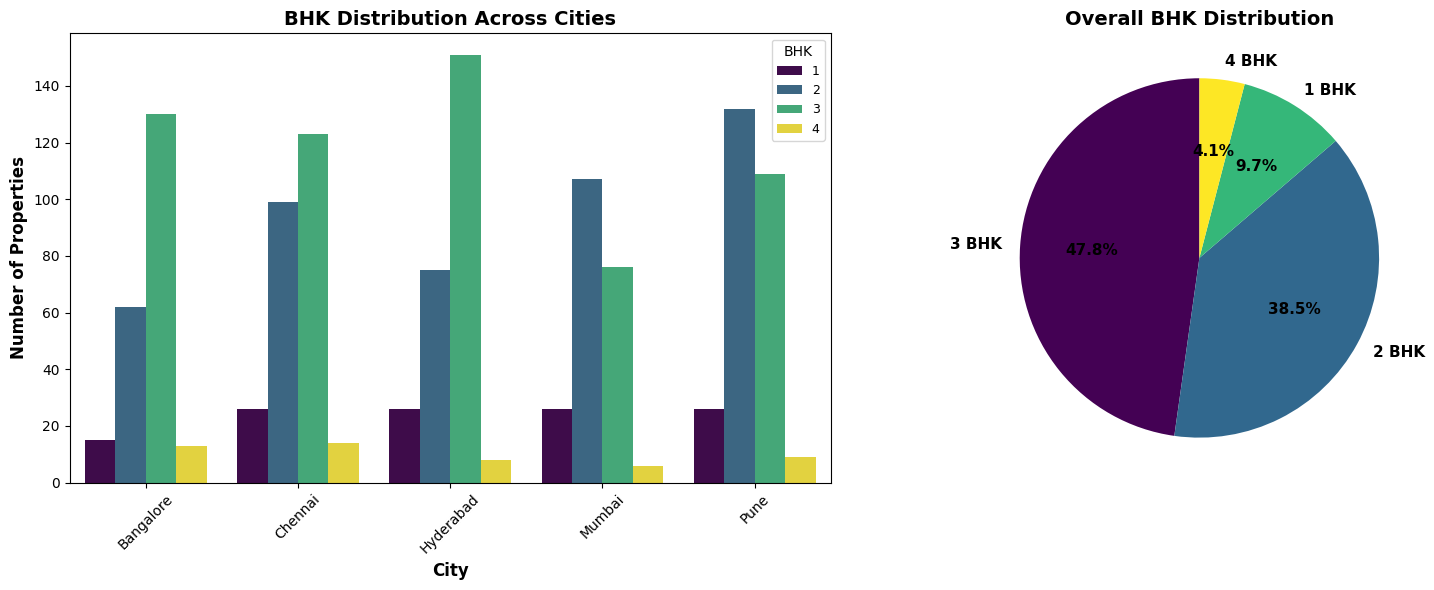

In [54]:
# ============================================================================
# 3. BHK DISTRIBUTION ACROSS CITIES
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
bhk_city = df.groupby(['City', 'BHK']).size().reset_index(name='Count')
sns.barplot(data=bhk_city, x='City', y='Count', hue='BHK', palette='viridis', ax=axes[0])
axes[0].set_title('BHK Distribution Across Cities', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='BHK', title_fontsize=10, fontsize=9)

# Pie chart for overall BHK distribution
bhk_counts = df['BHK'].value_counts()
colors_bhk = plt.cm.viridis(np.linspace(0, 1, len(bhk_counts)))
axes[1].pie(bhk_counts.values, labels=[f'{int(bhk)} BHK' for bhk in bhk_counts.index], 
            autopct='%1.1f%%', startangle=90, colors=colors_bhk, 
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Overall BHK Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('3_bhk_distribution.png', bbox_inches='tight')
plt.show()



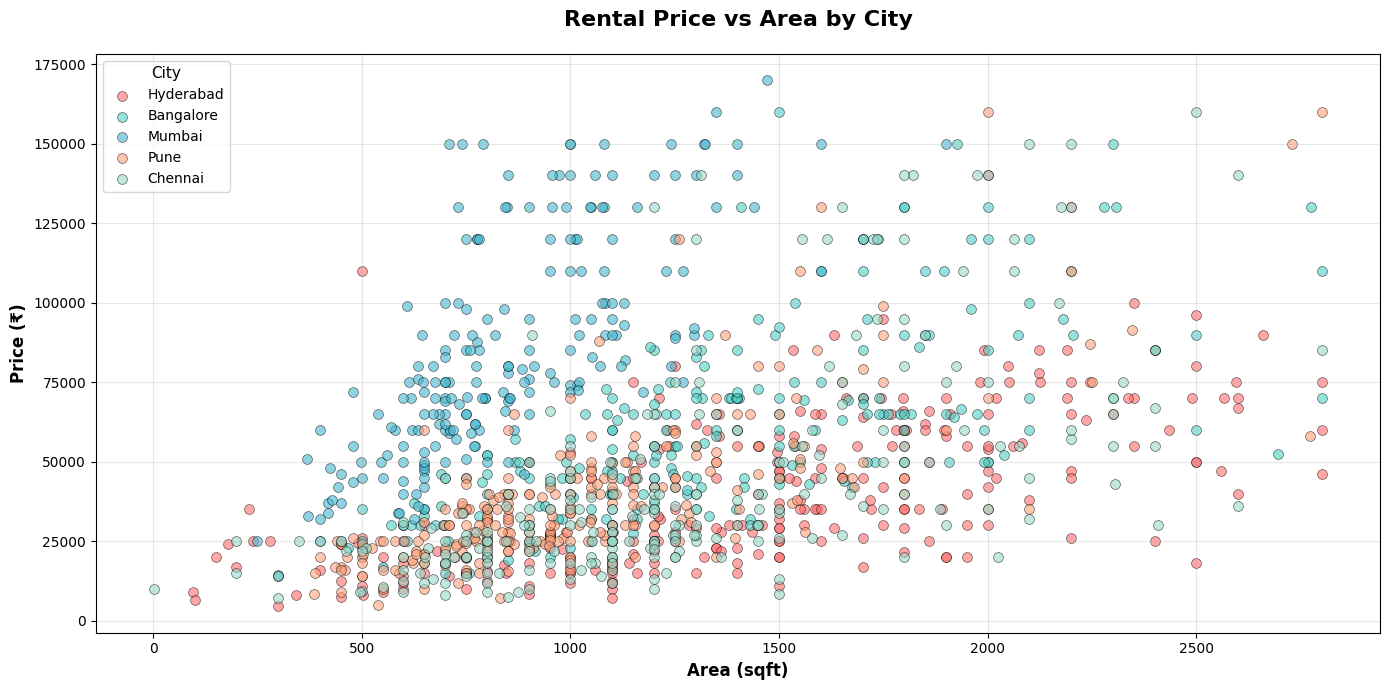

In [55]:
# ============================================================================
# 4. PRICE vs AREA SCATTER PLOT
# ============================================================================
plt.figure(figsize=(14, 7))
for city in df['City'].unique():
    city_data = df[df['City'] == city]
    plt.scatter(city_data['Area (sqft)'], city_data['Price'], 
                label=city, alpha=0.6, s=50, color=city_colors[city], edgecolors='black', linewidth=0.5)

plt.title('Rental Price vs Area by City', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Area (sqft)', fontsize=12, fontweight='bold')
plt.ylabel('Price (₹)', fontsize=12, fontweight='bold')
plt.legend(title='City', title_fontsize=11, fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('4_price_vs_area.png', bbox_inches='tight')
plt.show()



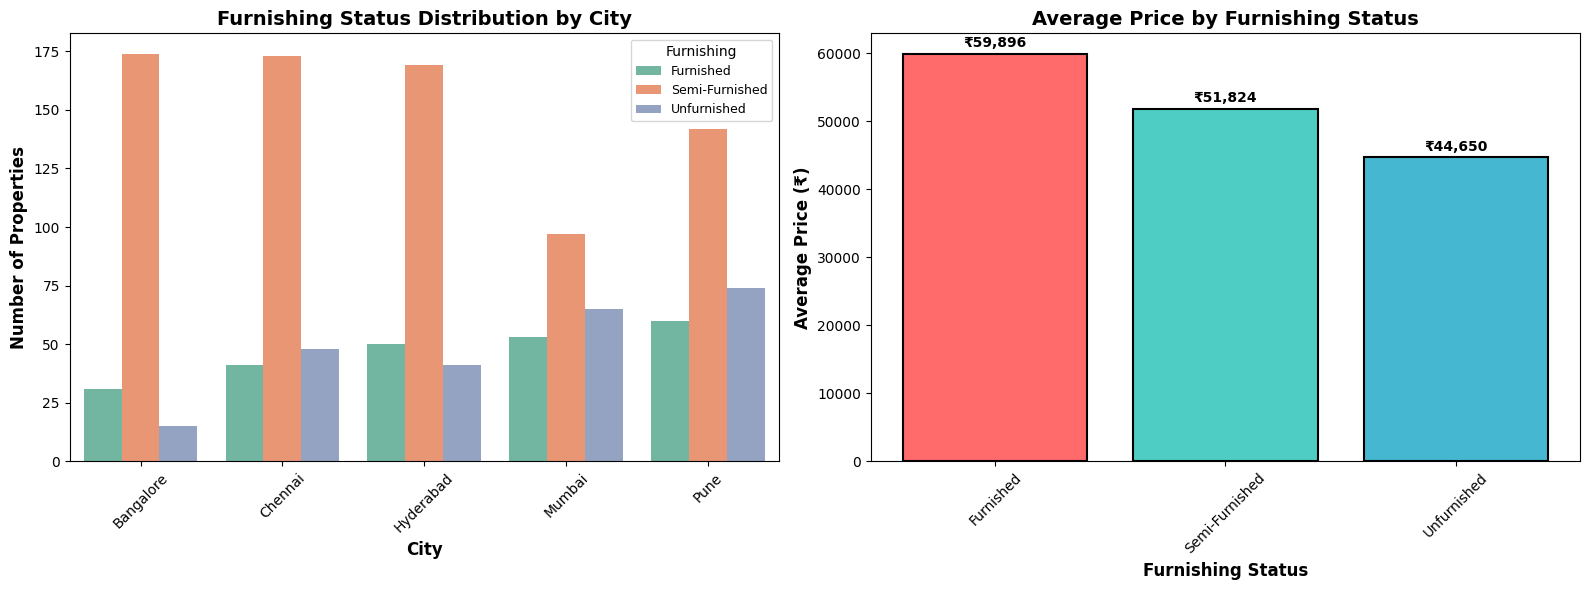

In [57]:
# ============================================================================
# 5. FURNISHING STATUS ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Furnishing count by city
furnishing_city = df.groupby(['City', 'Furnishing']).size().reset_index(name='Count')
sns.barplot(data=furnishing_city, x='City', y='Count', hue='Furnishing', 
            palette='Set2', ax=axes[0])
axes[0].set_title('Furnishing Status Distribution by City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Furnishing', title_fontsize=10, fontsize=9)

# Average price by furnishing
furnishing_price = df.groupby('Furnishing')['Price'].mean().sort_values(ascending=False)
colors_furn = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1].bar(furnishing_price.index, furnishing_price.values, color=colors_furn, 
            edgecolor='black', linewidth=1.5)
axes[1].set_title('Average Price by Furnishing Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Furnishing Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for i, (furn, value) in enumerate(furnishing_price.items()):
    axes[1].text(i, value + 500, f'₹{value:,.0f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('5_furnishing_analysis.png', bbox_inches='tight')
plt.show()



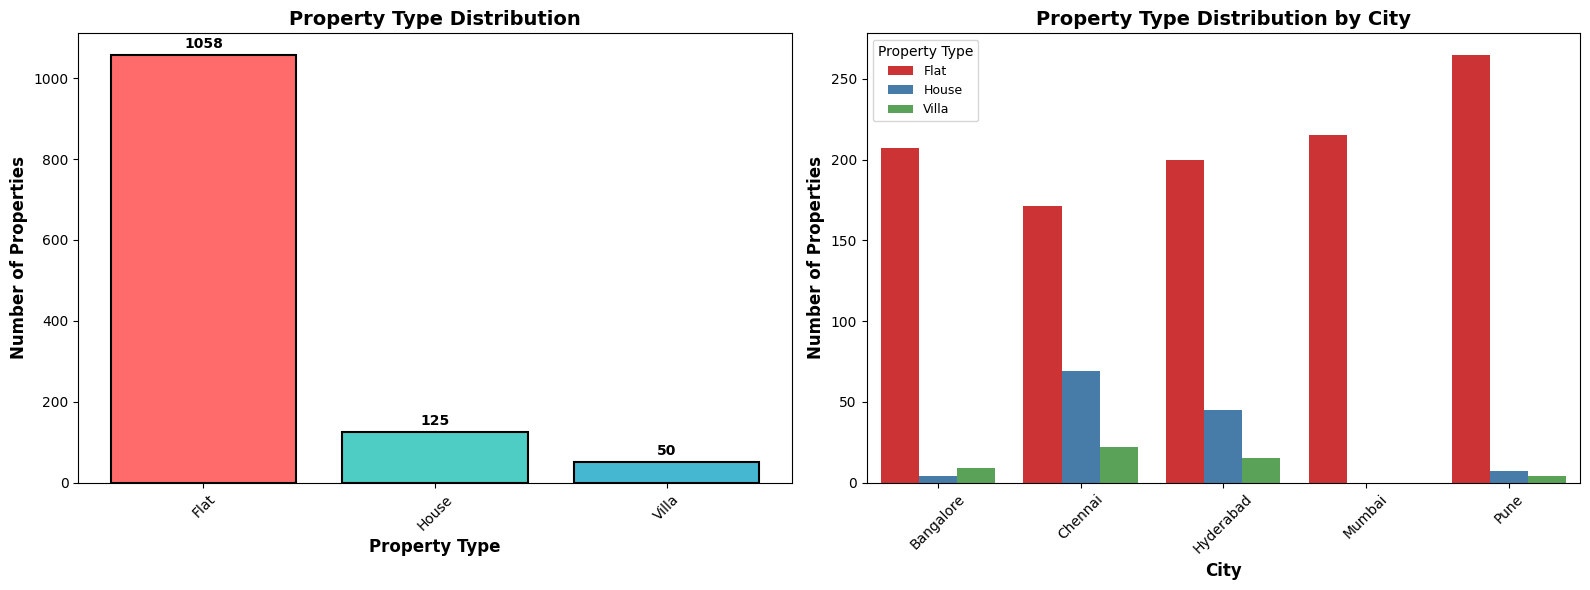

In [59]:
# ============================================================================
# 6. PROPERTY TYPE DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Property type count
prop_counts = df['Property Type'].value_counts()
colors_prop = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(prop_counts.index, prop_counts.values, color=colors_prop, 
            edgecolor='black', linewidth=1.5)
axes[0].set_title('Property Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Property Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (prop, value) in enumerate(prop_counts.items()):
    axes[0].text(i, value + 10, f'{value}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)

# Property type by city
prop_city = df.groupby(['City', 'Property Type']).size().reset_index(name='Count')
sns.barplot(data=prop_city, x='City', y='Count', hue='Property Type', 
            palette='Set1', ax=axes[1])
axes[1].set_title('Property Type Distribution by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Property Type', title_fontsize=10, fontsize=9)

plt.tight_layout()
plt.savefig('6_property_type_distribution.png', bbox_inches='tight')
plt.show()



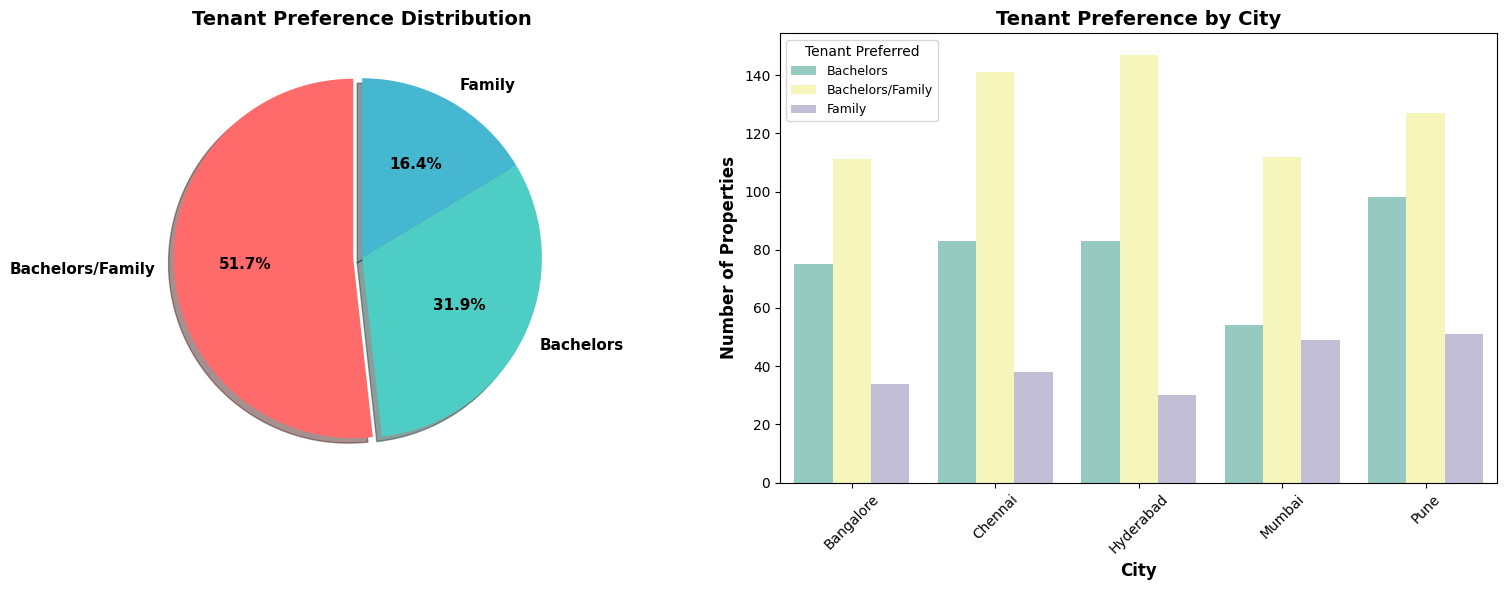

In [60]:
# ============================================================================
# 7. TENANT PREFERENCE ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenant preference distribution
tenant_counts = df['Tenant Preferred'].value_counts()
colors_tenant = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0, 0)
axes[0].pie(tenant_counts.values, labels=tenant_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors_tenant, explode=explode,
            textprops={'fontsize': 11, 'fontweight': 'bold'}, shadow=True)
axes[0].set_title('Tenant Preference Distribution', fontsize=14, fontweight='bold')

# Tenant preference by city
tenant_city = df.groupby(['City', 'Tenant Preferred']).size().reset_index(name='Count')
sns.barplot(data=tenant_city, x='City', y='Count', hue='Tenant Preferred', 
            palette='Set3', ax=axes[1])
axes[1].set_title('Tenant Preference by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Tenant Preferred', title_fontsize=10, fontsize=9)

plt.tight_layout()
plt.savefig('7_tenant_preference.png', bbox_inches='tight')
plt.show()



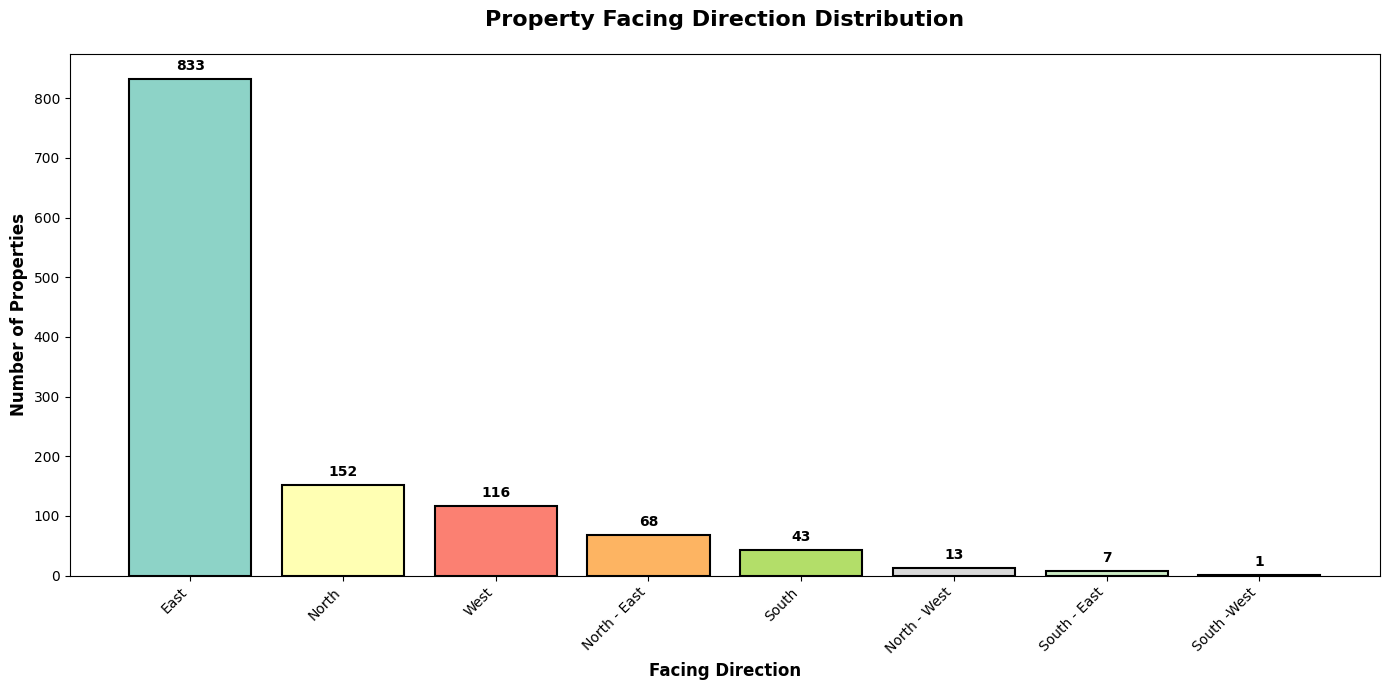

In [61]:
# ============================================================================
# 8. PROPERTY FACING DIRECTION ANALYSIS
# ============================================================================
plt.figure(figsize=(14, 7))
facing_counts = df['Property Facing'].value_counts().head(8)
colors_facing = plt.cm.Set3(np.linspace(0, 1, len(facing_counts)))

plt.bar(facing_counts.index, facing_counts.values, color=colors_facing, 
        edgecolor='black', linewidth=1.5)
plt.title('Property Facing Direction Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Facing Direction', fontsize=12, fontweight='bold')
plt.ylabel('Number of Properties', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, (facing, value) in enumerate(facing_counts.items()):
    plt.text(i, value + 10, f'{value}', ha='center', va='bottom', 
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('8_property_facing.png', bbox_inches='tight')
plt.show()



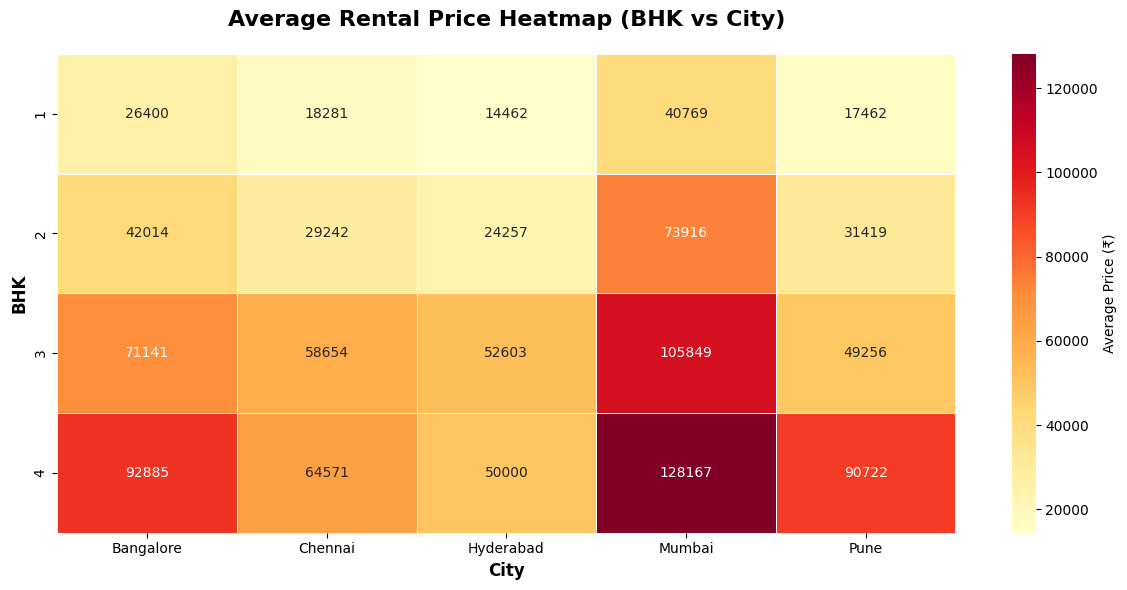

In [62]:
# ============================================================================
# 9. PRICE HEATMAP BY BHK AND CITY
# ============================================================================
plt.figure(figsize=(12, 6))
price_pivot = df.pivot_table(values='Price', index='BHK', columns='City', aggfunc='mean')
sns.heatmap(price_pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Average Price (₹)'})
plt.title('Average Rental Price Heatmap (BHK vs City)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('BHK', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('9_price_heatmap.png', bbox_inches='tight')
plt.show()



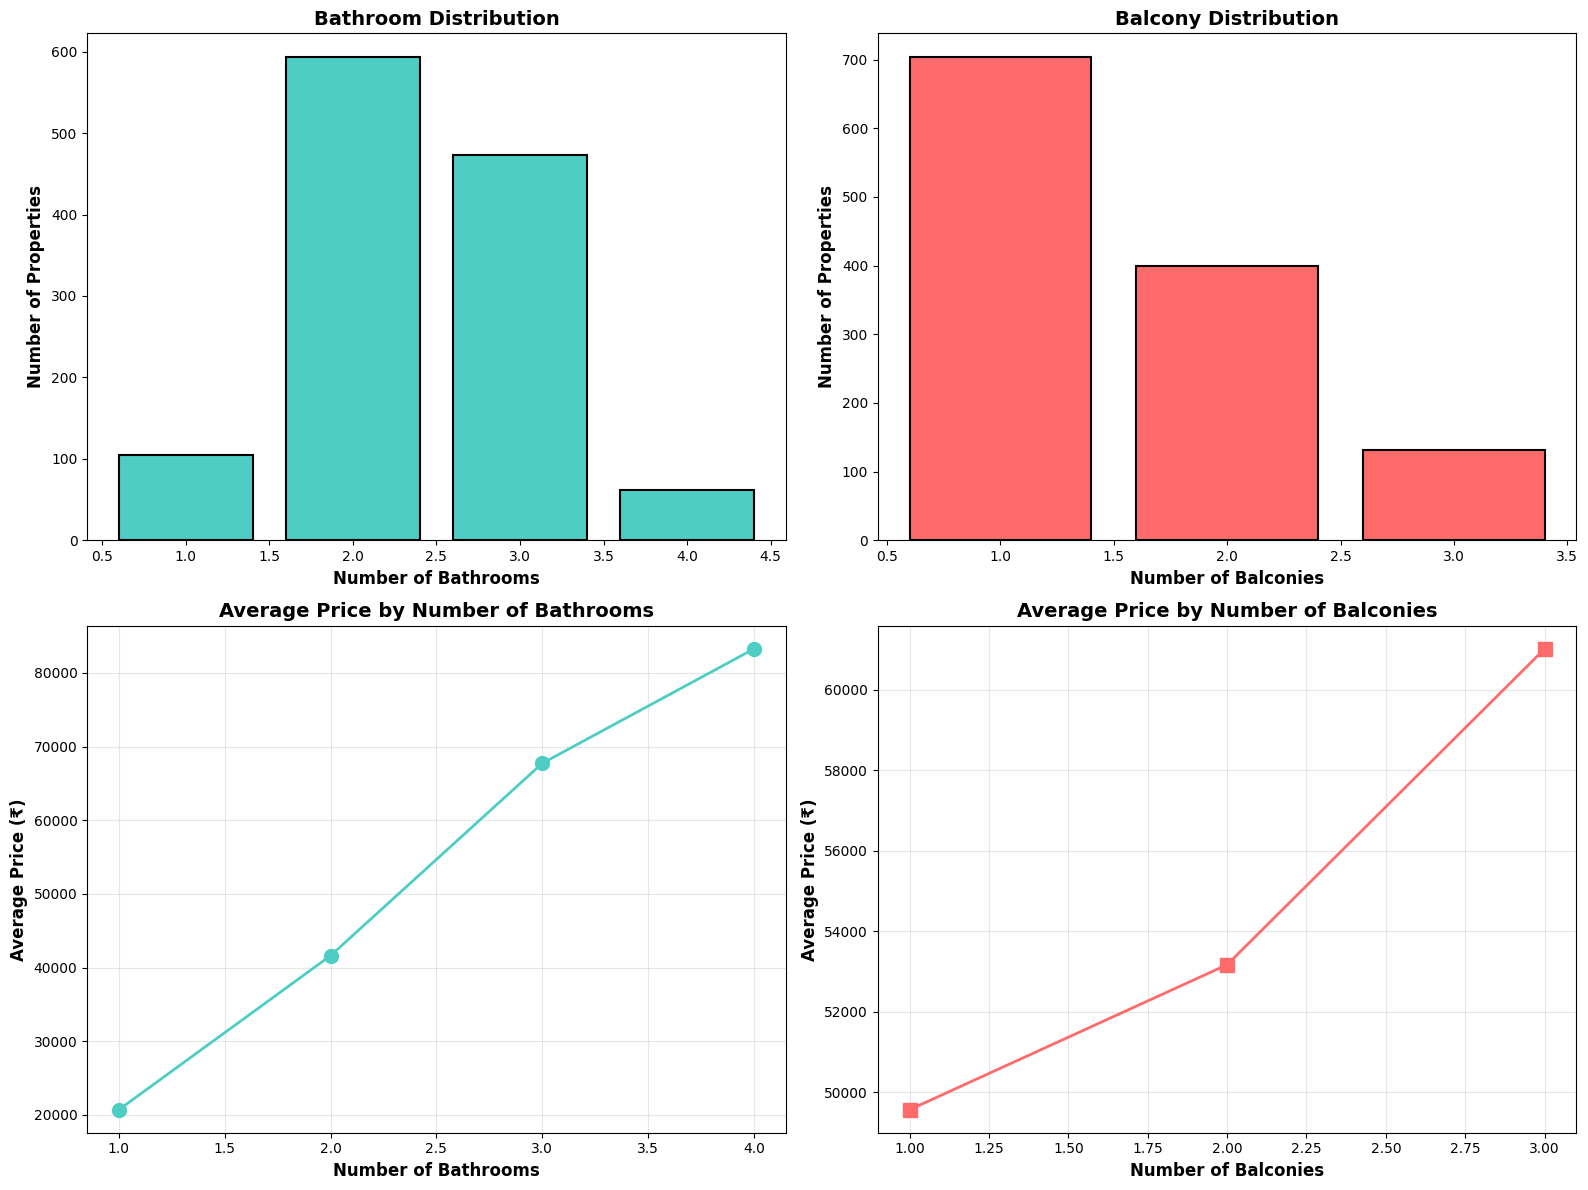

In [63]:
# ============================================================================
# 10. BATHROOM AND BALCONY ANALYSIS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bathroom distribution
bathroom_counts = df['Bathroom'].value_counts().sort_index()
axes[0, 0].bar(bathroom_counts.index, bathroom_counts.values, 
               color='#4ECDC4', edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Bathroom Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Bathrooms', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')

# Balcony distribution
balcony_counts = df['Balcony'].value_counts().sort_index()
axes[0, 1].bar(balcony_counts.index, balcony_counts.values, 
               color='#FF6B6B', edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Balcony Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Balconies', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')

# Price vs Bathroom
bathroom_price = df.groupby('Bathroom')['Price'].mean()
axes[1, 0].plot(bathroom_price.index, bathroom_price.values, 
                marker='o', linewidth=2, markersize=10, color='#4ECDC4')
axes[1, 0].set_title('Average Price by Number of Bathrooms', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Bathrooms', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Price vs Balcony
balcony_price = df.groupby('Balcony')['Price'].mean()
axes[1, 1].plot(balcony_price.index, balcony_price.values, 
                marker='s', linewidth=2, markersize=10, color='#FF6B6B')
axes[1, 1].set_title('Average Price by Number of Balconies', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Balconies', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('10_bathroom_balcony_analysis.png', bbox_inches='tight')
plt.show()



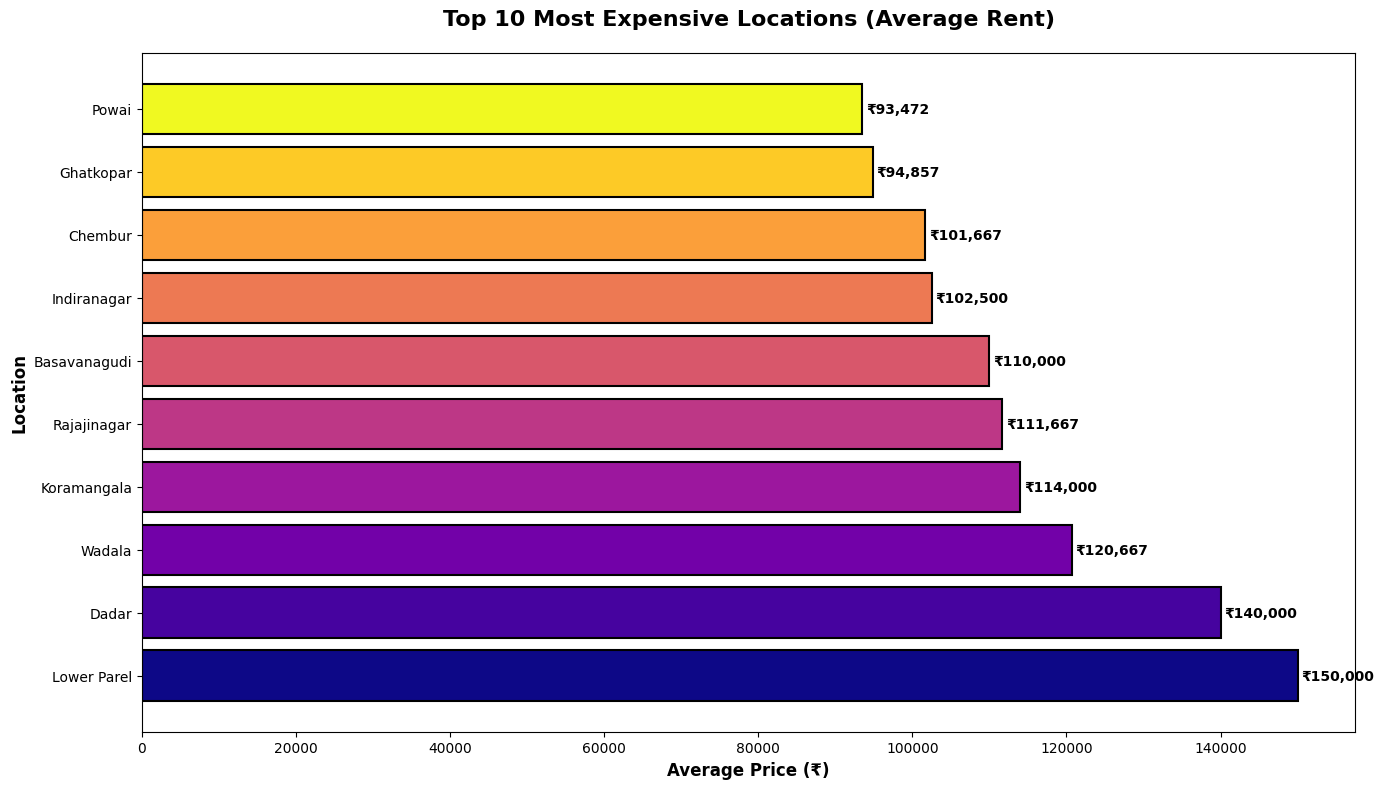

In [71]:
# ============================================================================
# 11. TOP 10 LOCATIONS BY AVERAGE PRICE
# ============================================================================
plt.figure(figsize=(14, 8))
top_locations = df.groupby('Location')['Price'].mean().sort_values(ascending=False).head(10)
colors_loc = plt.cm.plasma(np.linspace(0, 1, len(top_locations)))

plt.barh(top_locations.index, top_locations.values, color=colors_loc, 
         edgecolor='black', linewidth=1.5)
plt.title('Top 10 Most Expensive Locations (Average Rent)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Price (₹)', fontsize=12, fontweight='bold')
plt.ylabel('Location', fontsize=12, fontweight='bold')

# Add value labels
for i, (loc, value) in enumerate(top_locations.items()):
    plt.text(value + 500, i, f'₹{value:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('11_top_locations.png', bbox_inches='tight')
plt.show()



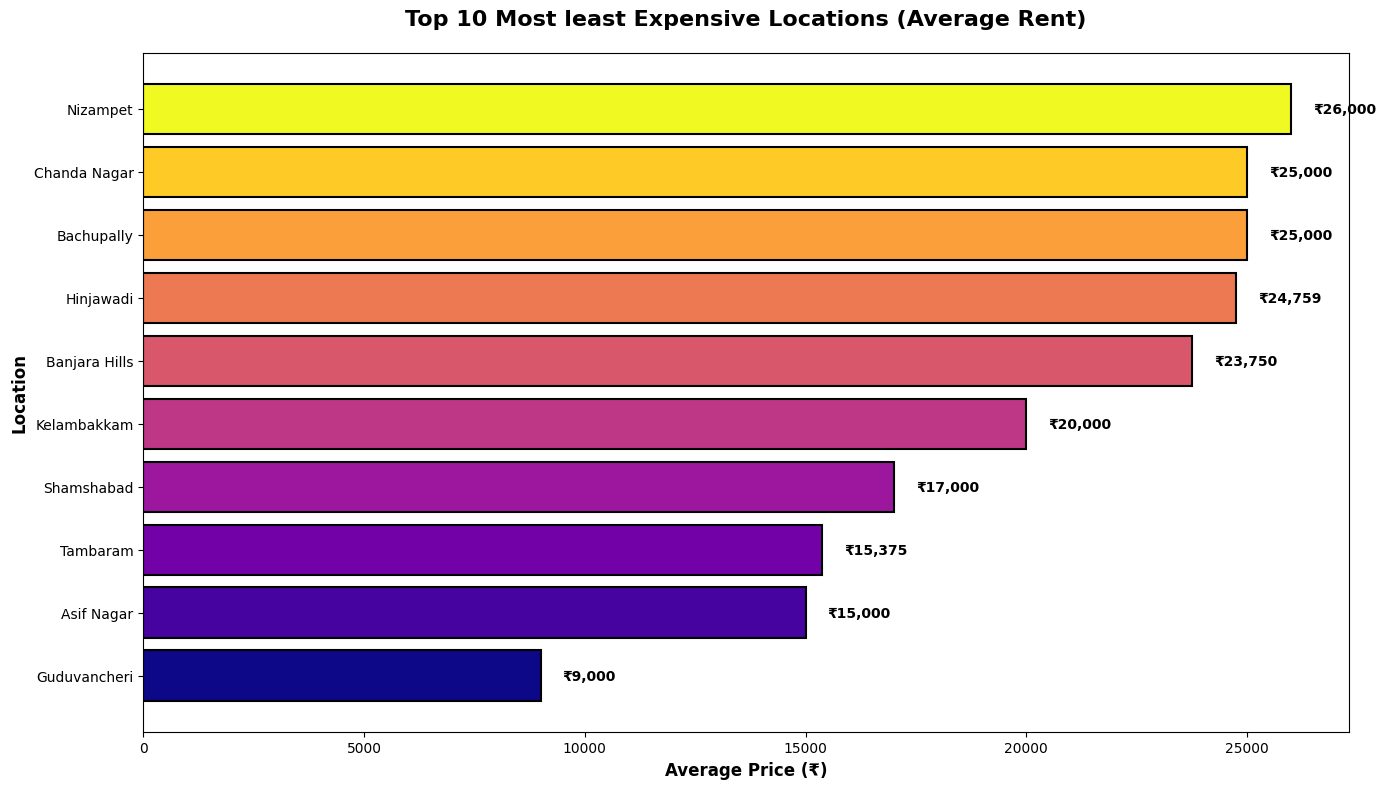

In [100]:
# ============================================================================
# 11. Least 10 LOCATIONS BY AVERAGE PRICE
# ============================================================================
plt.figure(figsize=(14, 8))
top_locations = df.groupby('Location')['Price'].mean().sort_values(ascending=True).head(10)
colors_loc = plt.cm.plasma(np.linspace(0, 1, len(top_locations)))

plt.barh(top_locations.index, top_locations.values, color=colors_loc, 
         edgecolor='black', linewidth=1.5)
plt.title('Top 10 Most least Expensive Locations (Average Rent)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Price (₹)', fontsize=12, fontweight='bold')
plt.ylabel('Location', fontsize=12, fontweight='bold')

# Add value labels
for i, (loc, value) in enumerate(top_locations.items()):
    plt.text(value + 500, i, f'₹{value:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('11_least_locations.png', bbox_inches='tight')
plt.show()



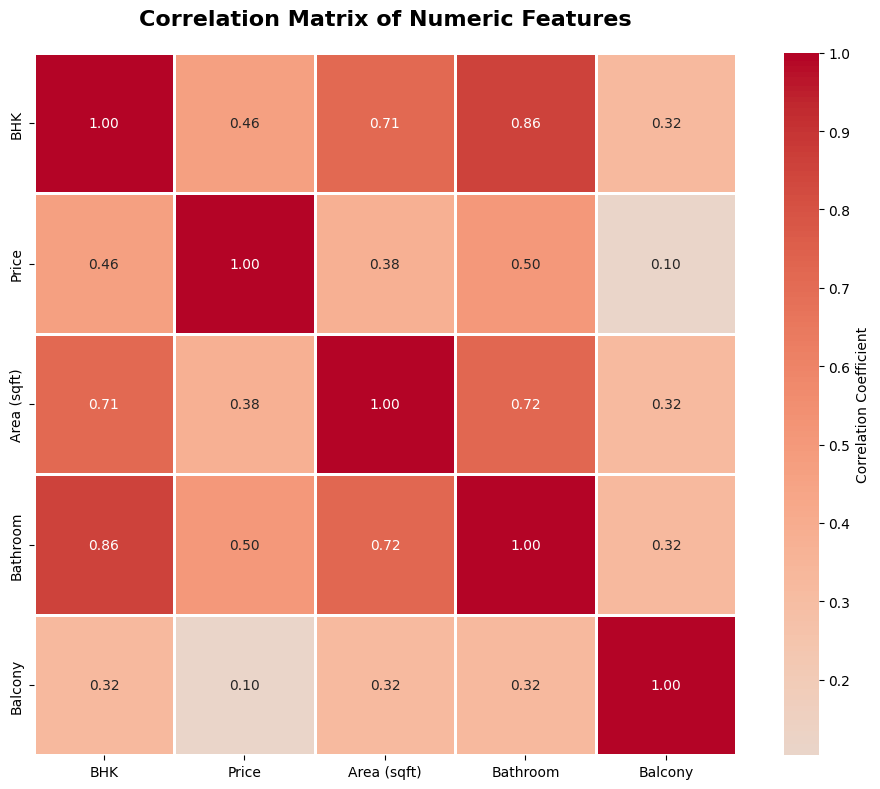

In [99]:
# ============================================================================
# 12. CORRELATION HEATMAP
# ============================================================================
plt.figure(figsize=(10, 8))
numeric_cols = ['BHK', 'Price', 'Area (sqft)', 'Bathroom', 'Balcony']
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('12_correlation_heatmap.png', bbox_inches='tight')
plt.show()



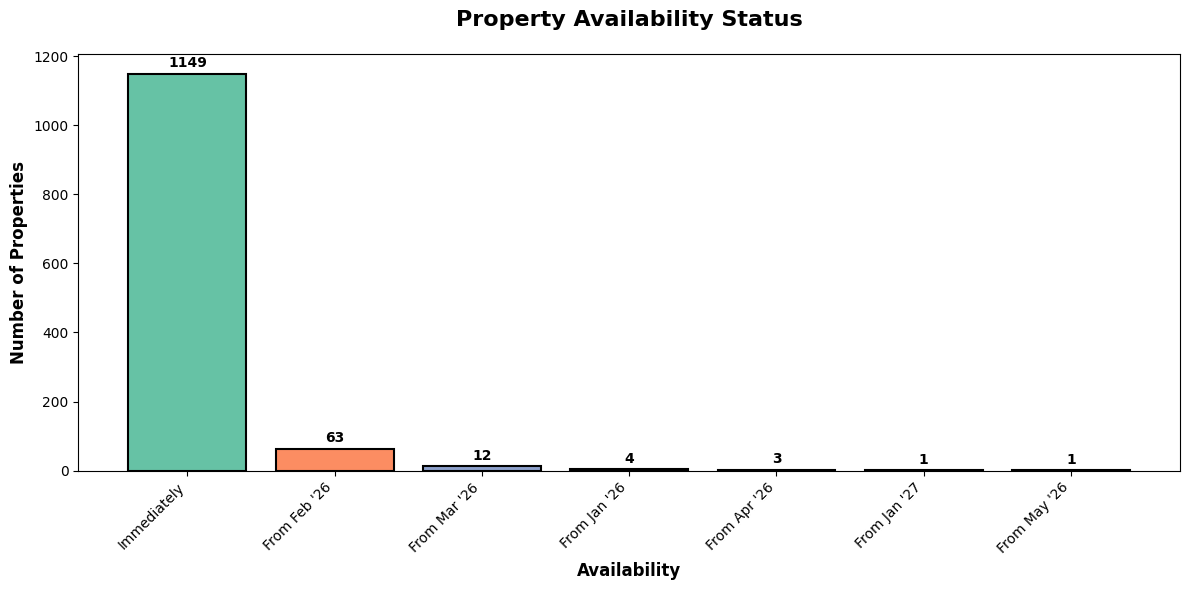

In [66]:
# ============================================================================
# 13. AVAILABILITY STATUS
# ============================================================================
plt.figure(figsize=(12, 6))
availability_counts = df['Availability'].value_counts()
colors_avail = plt.cm.Set2(np.linspace(0, 1, len(availability_counts)))

plt.bar(range(len(availability_counts)), availability_counts.values, 
        color=colors_avail, edgecolor='black', linewidth=1.5)
plt.xticks(range(len(availability_counts)), availability_counts.index, rotation=45, ha='right')
plt.title('Property Availability Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Availability', fontsize=12, fontweight='bold')
plt.ylabel('Number of Properties', fontsize=12, fontweight='bold')

# Add value labels
for i, value in enumerate(availability_counts.values):
    plt.text(i, value + 10, f'{value}', ha='center', va='bottom', 
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('13_availability_status.png', bbox_inches='tight')
plt.show()



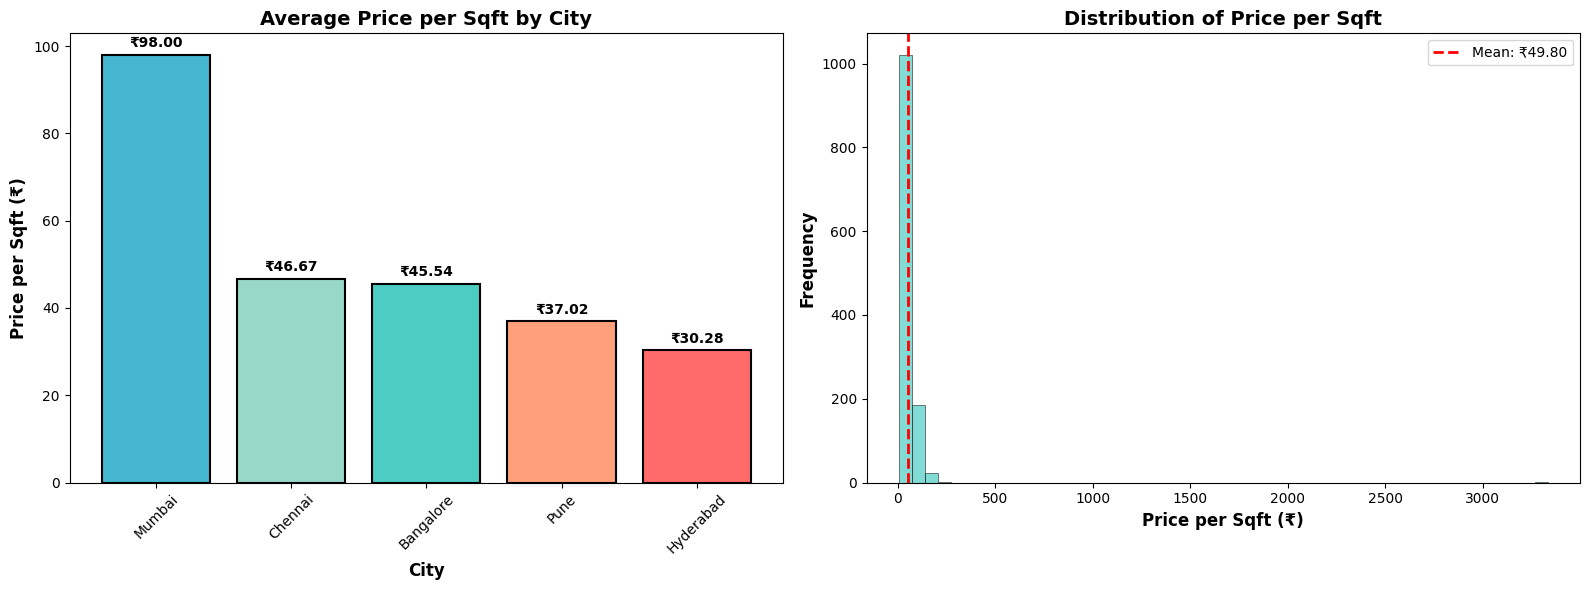

In [67]:
# ============================================================================
# 14. PRICE PER SQFT ANALYSIS
# ============================================================================
df['Price_per_sqft'] = df['Price'] / df['Area (sqft)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price per sqft by city
price_sqft_city = df.groupby('City')['Price_per_sqft'].mean().sort_values(ascending=False)
colors_sqft = [city_colors[city] for city in price_sqft_city.index]
axes[0].bar(price_sqft_city.index, price_sqft_city.values, color=colors_sqft, 
            edgecolor='black', linewidth=1.5)
axes[0].set_title('Average Price per Sqft by City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price per Sqft (₹)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (city, value) in enumerate(price_sqft_city.items()):
    axes[0].text(i, value + 1, f'₹{value:.2f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)

# Distribution of price per sqft
axes[1].hist(df['Price_per_sqft'], bins=50, color='#4ECDC4', 
             edgecolor='black', linewidth=0.5, alpha=0.7)
axes[1].set_title('Distribution of Price per Sqft', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price per Sqft (₹)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].axvline(df['Price_per_sqft'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: ₹{df["Price_per_sqft"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('14_price_per_sqft.png', bbox_inches='tight')
plt.show()



In [68]:
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)
print(f"\nTotal Properties Analyzed: {len(df)}")
print(f"Cities Covered: {', '.join(df['City'].unique())}")
print(f"\nPrice Statistics:")
print(f"  - Average Rent: ₹{df['Price'].mean():,.2f}")
print(f"  - Median Rent: ₹{df['Price'].median():,.2f}")
print(f"  - Min Rent: ₹{df['Price'].min():,.2f}")
print(f"  - Max Rent: ₹{df['Price'].max():,.2f}")
print(f"\nArea Statistics:")
print(f"  - Average Area: {df['Area (sqft)'].mean():,.2f} sqft")
print(f"  - Median Area: {df['Area (sqft)'].median():,.2f} sqft")
print(f"\nMost Common:")
print(f"  - BHK: {df['BHK'].mode()[0]}")
print(f"  - Furnishing: {df['Furnishing'].mode()[0]}")
print(f"  - Property Type: {df['Property Type'].mode()[0]}")
print(f"  - Tenant Preference: {df['Tenant Preferred'].mode()[0]}")
print("\n" + "="*80)
print("All visualizations have been saved successfully!")
print("="*80 + "\n")



EXPLORATORY DATA ANALYSIS SUMMARY

Total Properties Analyzed: 1233
Cities Covered: Hyderabad, Bangalore, Mumbai, Pune, Chennai

Price Statistics:
  - Average Rent: ₹51,948.94
  - Median Rent: ₹45,000.00
  - Min Rent: ₹4,500.00
  - Max Rent: ₹170,000.00

Area Statistics:
  - Average Area: 1,204.00 sqft
  - Median Area: 1,100.00 sqft

Most Common:
  - BHK: 3
  - Furnishing: Semi-Furnished
  - Property Type: Flat
  - Tenant Preference: Bachelors/Family

All visualizations have been saved successfully!

